<a href="https://colab.research.google.com/github/Altaieb-Mohammed/lab_2corse/blob/master/lab2_deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

url = "https://raw.githubusercontent.com/Altaieb-Mohammed/lab_2corse/master/Mall_Customers.csv"
df = pd.read_csv(url)
# Load the dataset


# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (200, 5)

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
No

Step 2: Data Preprocessing

In [2]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nNumber of duplicates: {df.duplicated().sum()}")

# Rename columns for easier access
df.columns = ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']
print("\nUpdated column names:", df.columns.tolist())

# Data types check
print("\nData types:")
print(df.dtypes)

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Number of duplicates: 0

Updated column names: ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']

Data types:
CustomerID        int64
Gender           object
Age               int64
AnnualIncome      int64
SpendingScore     int64
dtype: object


Step 3: Exploratory Data Analysis (EDA)

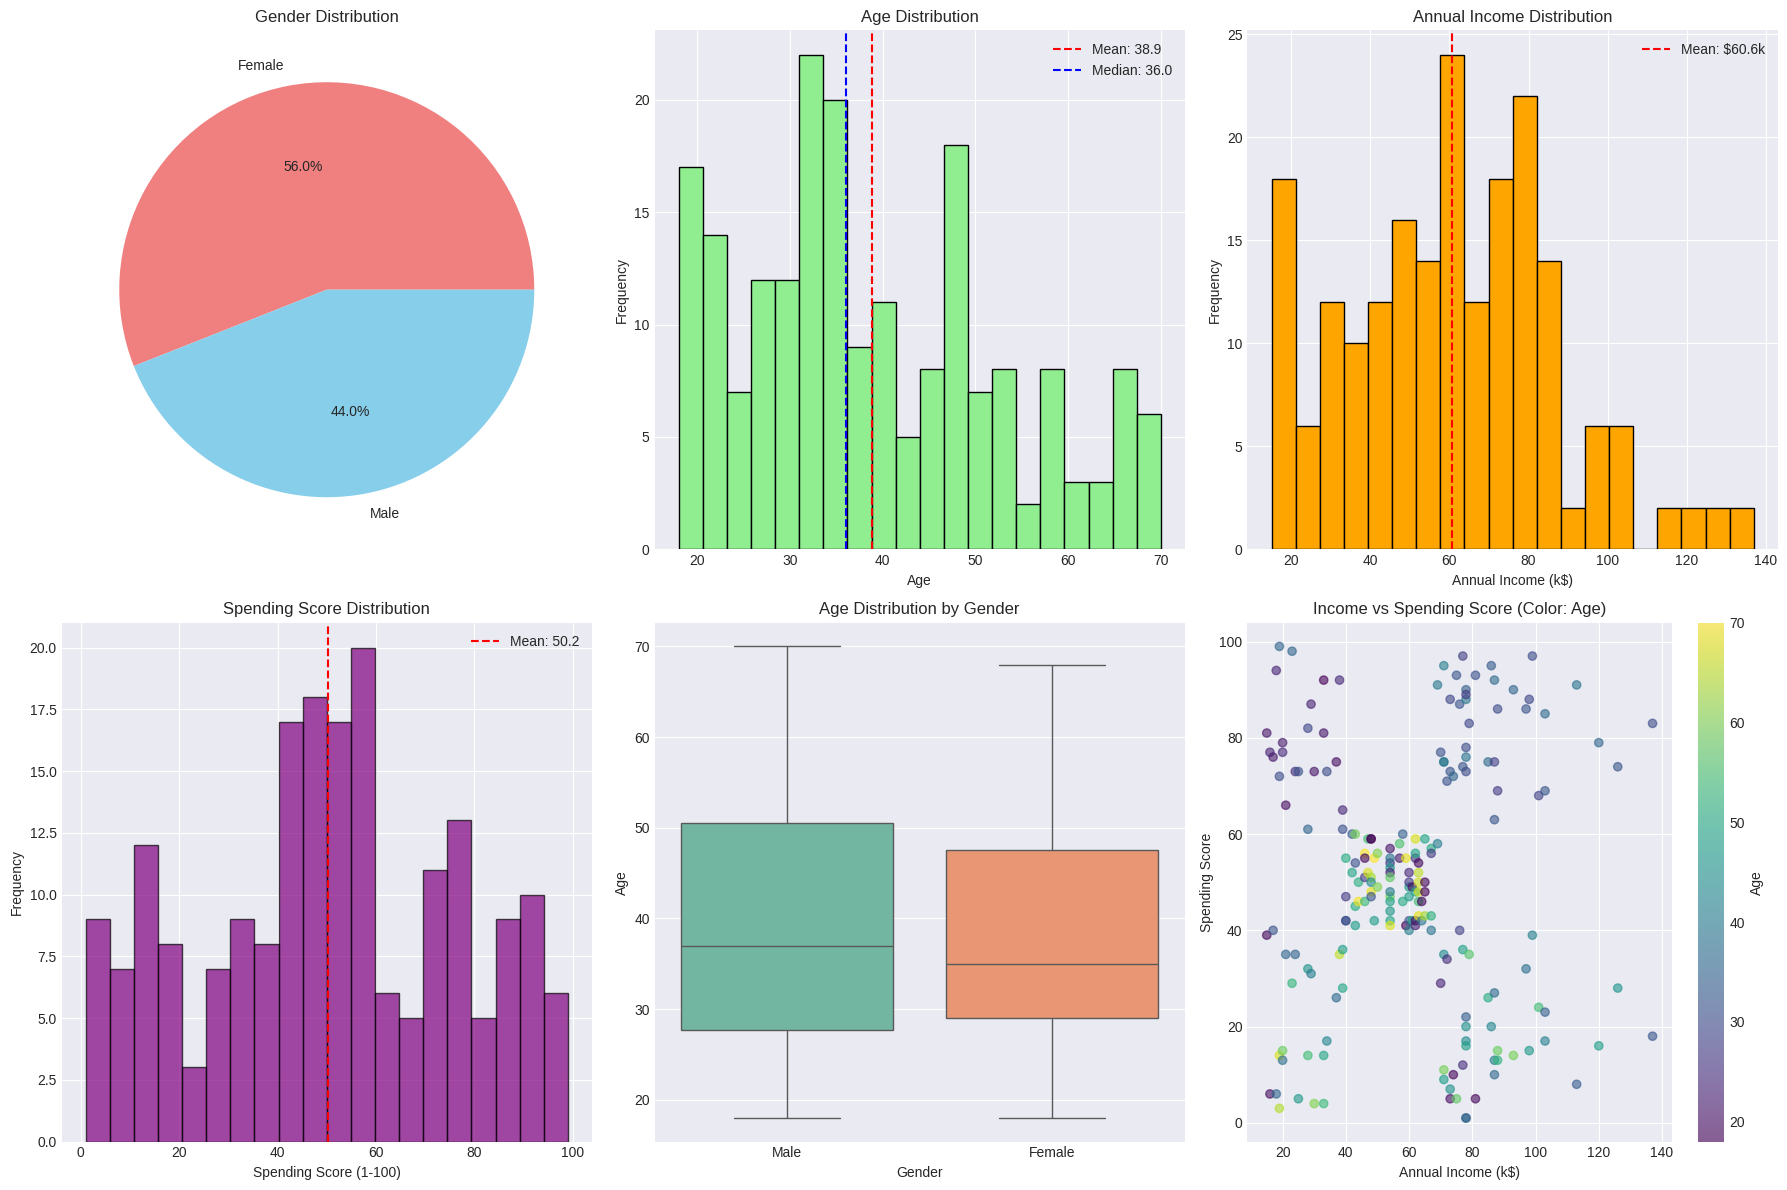

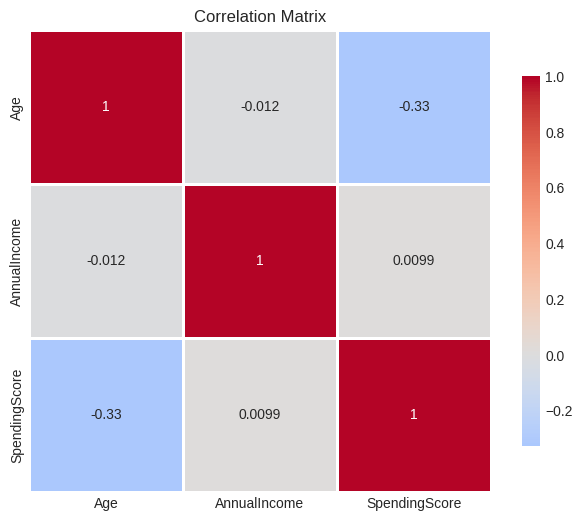

In [3]:
# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Gender Distribution
gender_counts = df['Gender'].value_counts()
axes[0, 0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'skyblue'])
axes[0, 0].set_title('Gender Distribution')

# 2. Age Distribution
axes[0, 1].hist(df['Age'], bins=20, edgecolor='black', color='lightgreen')
axes[0, 1].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
axes[0, 1].axvline(df['Age'].median(), color='blue', linestyle='--', label=f'Median: {df["Age"].median()}')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Age Distribution')
axes[0, 1].legend()

# 3. Annual Income Distribution
axes[0, 2].hist(df['AnnualIncome'], bins=20, edgecolor='black', color='orange')
axes[0, 2].axvline(df['AnnualIncome'].mean(), color='red', linestyle='--', label=f'Mean: ${df["AnnualIncome"].mean():.1f}k')
axes[0, 2].set_xlabel('Annual Income (k$)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Annual Income Distribution')
axes[0, 2].legend()

# 4. Spending Score Distribution
axes[1, 0].hist(df['SpendingScore'], bins=20, edgecolor='black', color='purple', alpha=0.7)
axes[1, 0].axvline(df['SpendingScore'].mean(), color='red', linestyle='--', label=f'Mean: {df["SpendingScore"].mean():.1f}')
axes[1, 0].set_xlabel('Spending Score (1-100)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Spending Score Distribution')
axes[1, 0].legend()

# 5. Boxplot for Age by Gender
sns.boxplot(x='Gender', y='Age', data=df, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Age Distribution by Gender')

# 6. Scatter plot: Income vs Spending Score
scatter = axes[1, 2].scatter(df['AnnualIncome'], df['SpendingScore'],
                             c=df['Age'], cmap='viridis', alpha=0.6)
axes[1, 2].set_xlabel('Annual Income (k$)')
axes[1, 2].set_ylabel('Spending Score')
axes[1, 2].set_title('Income vs Spending Score (Color: Age)')
plt.colorbar(scatter, ax=axes[1, 2], label='Age')

plt.tight_layout()
plt.show()

# Correlation matrix
numeric_cols = ['Age', 'AnnualIncome', 'SpendingScore']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix')
plt.show()

Step 4: Feature Engineering for Clustering


In [4]:
# Prepare data for clustering
# We'll use Age, Annual Income, and Spending Score for segmentation
X = df[['Age', 'AnnualIncome', 'SpendingScore']].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original data shape:", X.shape)
print("Scaled data (first 5 rows):")
print(X_scaled[:5])

Original data shape: (200, 3)
Scaled data (first 5 rows):
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


Step 5: Determine Optimal Number of Clusters (Elbow Method)

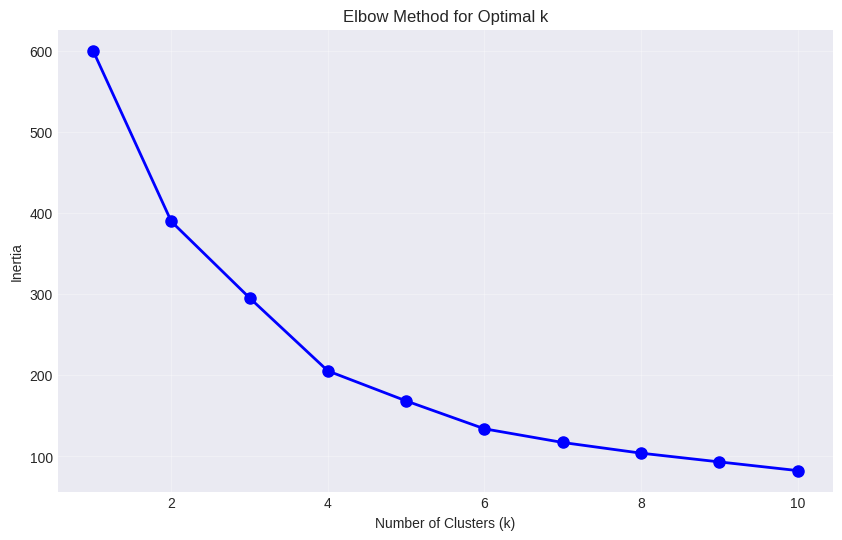

In [5]:
# Elbow Method to find optimal k
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.show()

Step 6: Apply K-Means Clustering

In [6]:
# Based on elbow method, let's choose k=5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Clustering with {optimal_k} clusters completed.")
print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# Add cluster centers back to original scale for interpretation
cluster_centers_scaled = kmeans.cluster_centers_
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)

cluster_centers_df = pd.DataFrame(
    cluster_centers_original,
    columns=['Age', 'AnnualIncome', 'SpendingScore']
)
cluster_centers_df.index.name = 'Cluster'
print("\nCluster Centers (original scale):")
print(cluster_centers_df)

Clustering with 5 clusters completed.

Cluster distribution:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

Cluster Centers (original scale):
               Age  AnnualIncome  SpendingScore
Cluster                                        
0        46.250000     26.750000      18.350000
1        25.185185     41.092593      62.240741
2        32.875000     86.100000      81.525000
3        39.871795     86.102564      19.358974
4        55.638298     54.382979      48.851064


Step 7: Visualize the Clusters

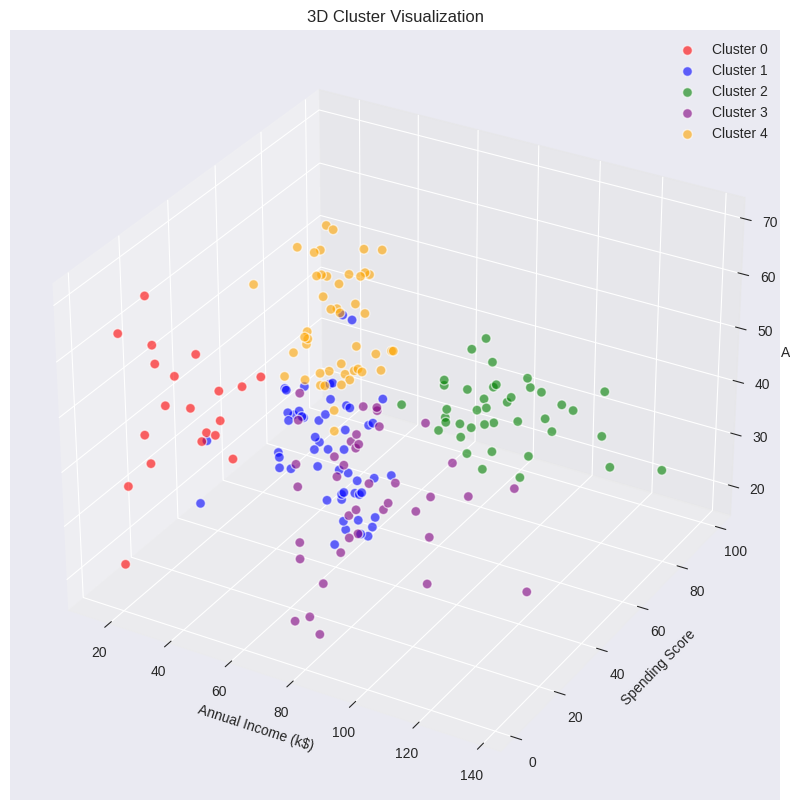

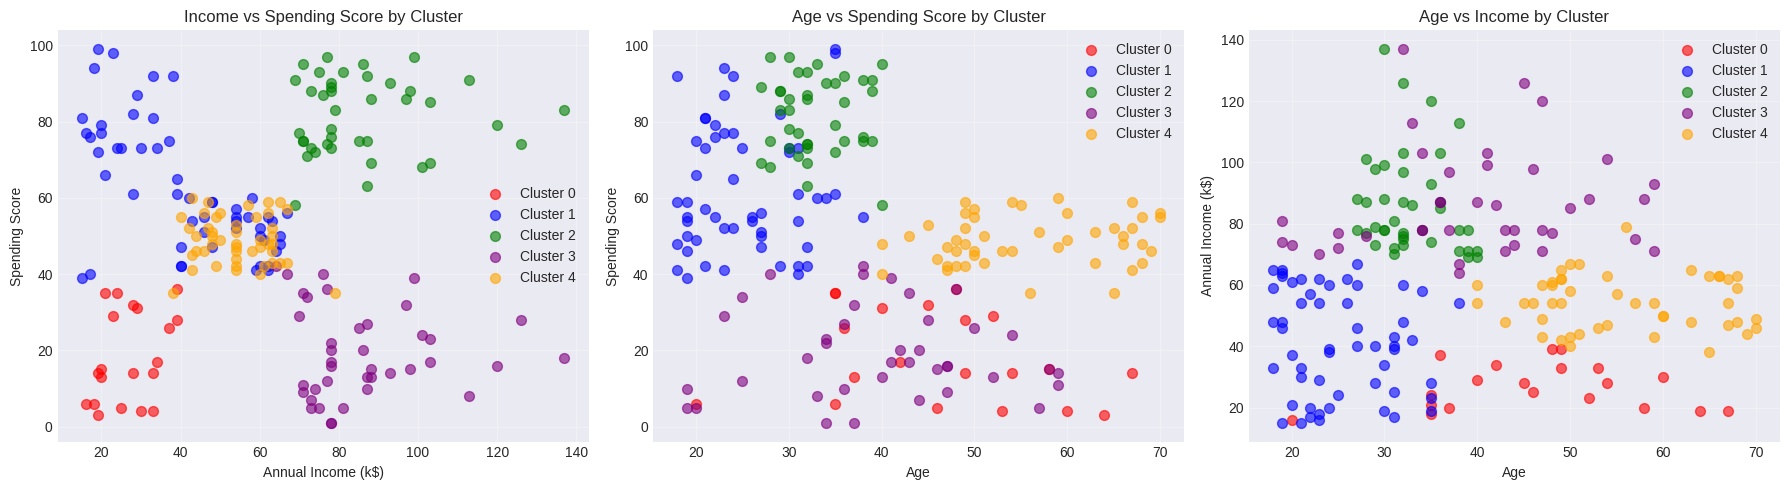

In [7]:
# Create 3D visualization of clusters
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Define colors for clusters
colors = ['red', 'blue', 'green', 'purple', 'orange']

# Plot each cluster
for cluster_id, color in zip(range(optimal_k), colors):
    cluster_data = df[df['Cluster'] == cluster_id]
    ax.scatter(cluster_data['AnnualIncome'],
               cluster_data['SpendingScore'],
               cluster_data['Age'],
               c=color, label=f'Cluster {cluster_id}',
               s=50, alpha=0.6, edgecolors='w')

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title('3D Cluster Visualization')
ax.legend()
plt.show()

# 2D Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Income vs Spending Score
for cluster_id, color in zip(range(optimal_k), colors):
    cluster_data = df[df['Cluster'] == cluster_id]
    axes[0].scatter(cluster_data['AnnualIncome'],
                    cluster_data['SpendingScore'],
                    c=color, label=f'Cluster {cluster_id}',
                    alpha=0.6, s=50)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')
axes[0].set_title('Income vs Spending Score by Cluster')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Age vs Spending Score
for cluster_id, color in zip(range(optimal_k), colors):
    cluster_data = df[df['Cluster'] == cluster_id]
    axes[1].scatter(cluster_data['Age'],
                    cluster_data['SpendingScore'],
                    c=color, label=f'Cluster {cluster_id}',
                    alpha=0.6, s=50)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score')
axes[1].set_title('Age vs Spending Score by Cluster')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Age vs Income
for cluster_id, color in zip(range(optimal_k), colors):
    cluster_data = df[df['Cluster'] == cluster_id]
    axes[2].scatter(cluster_data['Age'],
                    cluster_data['AnnualIncome'],
                    c=color, label=f'Cluster {cluster_id}',
                    alpha=0.6, s=50)
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Annual Income (k$)')
axes[2].set_title('Age vs Income by Cluster')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Step 8: Analyze and Profile Clusters

Cluster Profiles:
         Age_Mean  Age_Std  Age_Min  Age_Max  Income_Mean  Income_Std  \
Cluster                                                                 
0           46.25    11.58       20       67        26.75        7.31   
1           25.19     5.51       18       38        41.09       16.82   
2           32.88     3.86       27       40        86.10       16.34   
3           39.87    10.94       19       59        86.10       16.73   
4           55.64     8.91       40       70        54.38        8.82   

         Income_Min  Income_Max  Spending_Mean  Spending_Std  Spending_Min  \
Cluster                                                                      
0                16          39          18.35         11.94             3   
1                15          67          62.24         16.60            39   
2                69         137          81.53         10.00            58   
3                64         137          19.36         11.61             1   
4 

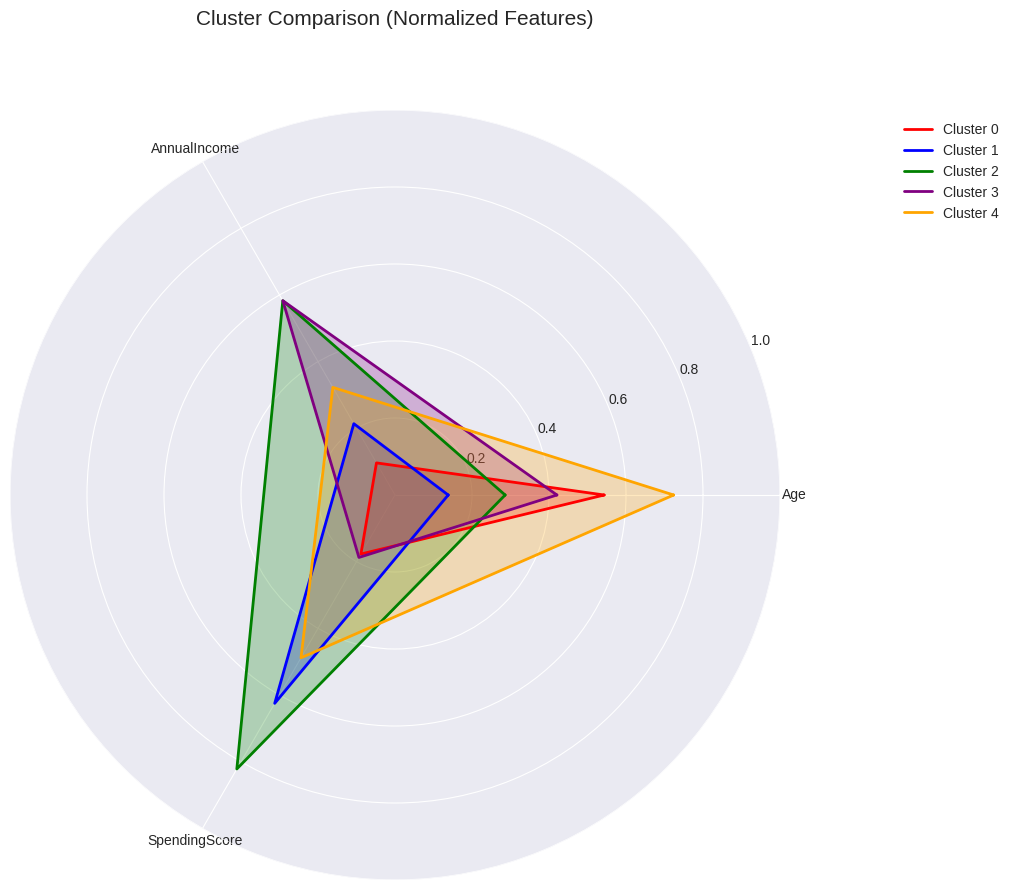

In [8]:
# Analyze cluster characteristics
cluster_profiles = df.groupby('Cluster').agg({
    'Age': ['mean', 'std', 'min', 'max'],
    'AnnualIncome': ['mean', 'std', 'min', 'max'],
    'SpendingScore': ['mean', 'std', 'min', 'max'],
    'Gender': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'CustomerID': 'count'
}).round(2)

# Rename columns for better readability
cluster_profiles.columns = ['Age_Mean', 'Age_Std', 'Age_Min', 'Age_Max',
                            'Income_Mean', 'Income_Std', 'Income_Min', 'Income_Max',
                            'Spending_Mean', 'Spending_Std', 'Spending_Min', 'Spending_Max',
                            'Dominant_Gender', 'Customer_Count']

print("Cluster Profiles:")
print(cluster_profiles)

# Create a radar chart for cluster comparison
from math import pi

# Normalize features for radar chart
features = ['Age', 'AnnualIncome', 'SpendingScore']
normalized_features = {}

for feature in features:
    min_val = df[feature].min()
    max_val = df[feature].max()
    normalized_features[feature] = (df.groupby('Cluster')[feature].mean() - min_val) / (max_val - min_val)

# Prepare data for radar chart
categories = list(normalized_features.keys())
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Close the loop

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

for cluster_id, color in zip(range(optimal_k), colors):
    values = [normalized_features[feature][cluster_id] for feature in categories]
    values += values[:1]  # Close the loop

    ax.plot(angles, values, color=color, linewidth=2, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, color=color, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Cluster Comparison (Normalized Features)', size=15, y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.show()

Step 9: Interpretation and Business Insights

In [9]:
print("="*80)
print("CLUSTER INTERPRETATION AND BUSINESS INSIGHTS")
print("="*80)

# Create a detailed interpretation based on cluster centers
cluster_descriptions = []

for cluster_id in range(optimal_k):
    age_mean = cluster_profiles.loc[cluster_id, 'Age_Mean']
    income_mean = cluster_profiles.loc[cluster_id, 'Income_Mean']
    spending_mean = cluster_profiles.loc[cluster_id, 'Spending_Mean']
    count = cluster_profiles.loc[cluster_id, 'Customer_Count']
    gender = cluster_profiles.loc[cluster_id, 'Dominant_Gender']

    # Determine cluster characteristics
    if age_mean < 30:
        age_group = "Young"
    elif age_mean < 50:
        age_group = "Middle-aged"
    else:
        age_group = "Senior"

    if income_mean < 40:
        income_group = "Low income"
    elif income_mean < 70:
        income_group = "Middle income"
    else:
        income_group = "High income"

    if spending_mean < 40:
        spending_group = "Low spender"
    elif spending_mean < 60:
        spending_group = "Moderate spender"
    else:
        spending_group = "High spender"

    description = f"""
    Cluster {cluster_id} ({count} customers, {gender}-dominated):
    - {age_group} customers (Average age: {age_mean:.1f} years)
    - {income_group} (Average income: ${income_mean:.1f}k)
    - {spending_group} (Average spending score: {spending_mean:.1f})
    """
    cluster_descriptions.append(description)

for desc in cluster_descriptions:
    print(desc)

print("\n" + "="*80)
print("RECOMMENDATIONS FOR MARKETING STRATEGY:")
print("="*80)

recommendations = [
    "1. Target high-spending clusters with premium products and loyalty programs",
    "2. Develop personalized marketing campaigns for each segment",
    "3. Create age-appropriate promotions and product recommendations",
    "4. Focus on converting moderate spenders to high spenders through targeted offers",
    "5. Use cluster insights to optimize store layout and product placement"
]

for rec in recommendations:
    print(rec)

CLUSTER INTERPRETATION AND BUSINESS INSIGHTS

    Cluster 0 (20 customers, Female-dominated):
    - Middle-aged customers (Average age: 46.2 years)
    - Low income (Average income: $26.8k)
    - Low spender (Average spending score: 18.4)
    

    Cluster 1 (54 customers, Female-dominated):
    - Young customers (Average age: 25.2 years)
    - Middle income (Average income: $41.1k)
    - High spender (Average spending score: 62.2)
    

    Cluster 2 (40 customers, Female-dominated):
    - Middle-aged customers (Average age: 32.9 years)
    - High income (Average income: $86.1k)
    - High spender (Average spending score: 81.5)
    

    Cluster 3 (39 customers, Male-dominated):
    - Middle-aged customers (Average age: 39.9 years)
    - High income (Average income: $86.1k)
    - Low spender (Average spending score: 19.4)
    

    Cluster 4 (47 customers, Female-dominated):
    - Senior customers (Average age: 55.6 years)
    - Middle income (Average income: $54.4k)
    - Moderate sp

Step 10: Export Results

In [10]:
# Save the clustered data
df.to_csv('Mall_Customers_Clustered.csv', index=False)
print("\nClustered data saved to 'Mall_Customers_Clustered.csv'")

# Save cluster profiles
cluster_profiles.to_csv('Cluster_Profiles.csv')
print("Cluster profiles saved to 'Cluster_Profiles.csv'")

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Total Customers: {len(df)}")
print(f"Gender Distribution: {df['Gender'].value_counts().to_dict()}")
print(f"Average Age: {df['Age'].mean():.1f} years")
print(f"Average Annual Income: ${df['AnnualIncome'].mean():.1f}k")
print(f"Average Spending Score: {df['SpendingScore'].mean():.1f}")


Clustered data saved to 'Mall_Customers_Clustered.csv'
Cluster profiles saved to 'Cluster_Profiles.csv'

SUMMARY STATISTICS
Total Customers: 200
Gender Distribution: {'Female': 112, 'Male': 88}
Average Age: 38.9 years
Average Annual Income: $60.6k
Average Spending Score: 50.2
